Library Import & Data Loading

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [3]:
BASE_DIR = Path.cwd()


while BASE_DIR.name != "Final_Project":
    BASE_DIR = BASE_DIR.parent


os.chdir(BASE_DIR)

print(os.getcwd())

CLEANED_DIR = BASE_DIR / "data" / "cleaned"
CLEANED_DIR.mkdir(parents=True,exist_ok=True)

c:\Users\sever\Documents\Project_Coolyeah\Lab_MCI\Final_Project


In [4]:
spark = SparkSession.builder \
    .appName("CustomerReviewEDA") \
    .getOrCreate()

reviews_df = spark.read.csv(
    "data/raw/order_reviews.csv",
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"',
    quote='"',
    mode="DROPMALFORMED"
)

orders_df = spark.read.csv(
    "data/raw/orders.csv",
    header=True,
    inferSchema=True
)

items_df = spark.read.csv(
    "data/raw/order_items.csv",
    header=True,
    inferSchema=True
)

products_df = spark.read.csv(
    "data/raw/products.csv",
    header=True,
    inferSchema=True
)

customers_df = spark.read.csv(
    "data/raw/customers.csv",
    header=True,
    inferSchema=True
)

sellers_df = spark.read.csv(
    "data/raw/sellers.csv",
    header=True,
    inferSchema=True
)

translation_df = spark.read.csv(
    "data/raw/category_translation.csv",
    header=True,
    inferSchema=True
)

DATA SELECTION

In [5]:
reviews_df = reviews_df.select(
    "review_id",
    "order_id",
    "review_score",
    "review_comment_message"
)

reviews_df = reviews_df.withColumn(
    "sentiment",
    when(col("review_score") <= 2, "negative")
    .when(col("review_score") == 3, "neutral")
    .otherwise("positive")
)

orders_df = orders_df.select(
    "order_id",
    "customer_id",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
)

orders_df = orders_df.filter(
    (col("order_status") == "delivered")
)

orders_df = orders_df.withColumn(
    "delivery_delay_days",
    datediff(
        col("order_delivered_customer_date"),
        col("order_estimated_delivery_date")
    )
)

orders_df = orders_df.withColumn(
    "delivery_status",
    when(
        col("delivery_delay_days") > 0,
        "late"
    ).when(
        col("delivery_delay_days") < 0,
        "early"
    ).otherwise("on_time")
)

items_df = items_df.select(
    "order_id",
    "product_id",
    "seller_id",
    "price",
    "freight_value"
)

products_df = products_df.select(
    "product_id",
    "product_category_name"
)

customers_selected = customers_df.select(
    "customer_id",
    "customer_city",
    "customer_state"
)


sellers_selected = sellers_df.select(
    "seller_id",
    "seller_city",
    "seller_state"
)


translation_df = translation_df.select(
    "product_category_name",
    "product_category_name_english"
)


Data Exploration

In [6]:
def basic_eda(df, name):

    print(f"\n===== {name} =====")

    # TOTAL ROWS & COLUMNS

    print("\nTotal Rows:")
    print(df.count())

    print("\nTotal Columns:")
    print(len(df.columns))


    # SCHEMA

    print("\n===== SCHEMA =====")

    df.printSchema()


    # SAMPLE DATA

    print("\n===== SAMPLE DATA =====")

    df.show(5, truncate=False)


    # MISSING VALUES

    print("\n===== MISSING VALUES =====")

    missing_df = df.select([
        count(
            when(
                col(c).isNull(),
                c
            )
        ).alias(c)
        for c in df.columns
    ])

    missing_df.show()

In [7]:
basic_eda(reviews_df, "REVIEWS DATASET")


===== REVIEWS DATASET =====

Total Rows:
99224

Total Columns:
5

===== SCHEMA =====
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: integer (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- sentiment: string (nullable = false)


===== SAMPLE DATA =====
+--------------------------------+--------------------------------+------------+----------------------------------------------------------------------------------------------------+---------+
|review_id                       |order_id                        |review_score|review_comment_message                                                                              |sentiment|
+--------------------------------+--------------------------------+------------+----------------------------------------------------------------------------------------------------+---------+
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|4           |NULL 

In [8]:
print("\n===== DUPLICATE REVIEW_ID =====")

duplicate_review = (
    reviews_df.groupBy("review_id")
    .count()
    .filter(col("count") > 1)
)

print("Duplicate count:", duplicate_review.count())


===== DUPLICATE REVIEW_ID =====
Duplicate count: 789


In [9]:
basic_eda(orders_df, "ORDERS DATASET")


===== ORDERS DATASET =====

Total Rows:
96478

Total Columns:
8

===== SCHEMA =====
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- delivery_status: string (nullable = false)


===== SAMPLE DATA =====
+--------------------------------+--------------------------------+------------+------------------------+-----------------------------+-----------------------------+-------------------+---------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_delivered_customer_date|order_estimated_delivery_date|delivery_delay_days|delivery_status|
+--------------------------------+--------------------------------

In [10]:
basic_eda(items_df, "ORDER ITEMS DATASET")


===== ORDER ITEMS DATASET =====

Total Rows:
112650

Total Columns:
5

===== SCHEMA =====
root
 |-- order_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


===== SAMPLE DATA =====
+--------------------------------+--------------------------------+--------------------------------+-----+-------------+
|order_id                        |product_id                      |seller_id                       |price|freight_value|
+--------------------------------+--------------------------------+--------------------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|58.9 |13.29        |
|00018f77f2f0320c557190d7a144bdd3|e5f2d52b802189ee658865ca93d83a8f|dd7ddc04e1b6c2c614352b383efe2d36|239.9|19.93        |
|000229ec398224ef6ca0657da4fc703e|c777355d18b72b67abbeef9df44fd0fd|5

In [11]:
basic_eda(products_df, "PRODUCTS DATASET")


===== PRODUCTS DATASET =====

Total Rows:
32951

Total Columns:
2

===== SCHEMA =====
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)


===== SAMPLE DATA =====
+--------------------------------+---------------------+
|product_id                      |product_category_name|
+--------------------------------+---------------------+
|1e9e8ef04dbcff4541ed26657ea517e5|perfumaria           |
|3aa071139cb16b67ca9e5dea641aaa2f|artes                |
|96bd76ec8810374ed1b65e291975717f|esporte_lazer        |
|cef67bcfe19066a932b7673e239eb23d|bebes                |
|9dc1a7de274444849c219cff195d0b71|utilidades_domesticas|
+--------------------------------+---------------------+
only showing top 5 rows

===== MISSING VALUES =====
+----------+---------------------+
|product_id|product_category_name|
+----------+---------------------+
|         0|                  610|
+----------+---------------------+



In [12]:
print("\n===== DUPLICATE PRODUCT_ID =====")

duplicate_products = (
    products_df.groupBy("product_id")
    .count()
    .filter(col("count") > 1)
)

print("Duplicate count:", duplicate_products.count())


===== DUPLICATE PRODUCT_ID =====
Duplicate count: 0


In [13]:
basic_eda(customers_selected, "CUSTOMERS DATASET")


===== CUSTOMERS DATASET =====

Total Rows:
99441

Total Columns:
3

===== SCHEMA =====
root
 |-- customer_id: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


===== SAMPLE DATA =====
+--------------------------------+---------------------+--------------+
|customer_id                     |customer_city        |customer_state|
+--------------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|sao paulo            |SP            |
|b2b6027bc5c5109e529d4dc6358b12c3|mogi das cruzes      |SP            |
|4f2d8ab171c80ec8364f7c12e35b23ad|campinas             |SP            |
+--------------------------------+---------------------+--------------+
only showing top 5 rows

===== MISSING VALUES =====
+-----------+-------------+--------------+
|cus

In [14]:
print("\n===== DUPLICATE CUSTOMERS_ID =====")

duplicate_customers = (
    customers_selected.groupBy("customer_id")
    .count()
    .filter(col("count") > 1)
)

print("Duplicate count:", duplicate_review.count())


===== DUPLICATE CUSTOMERS_ID =====
Duplicate count: 789


In [15]:
basic_eda(sellers_selected, "SELLERS DATASET")


===== SELLERS DATASET =====

Total Rows:
3095

Total Columns:
3

===== SCHEMA =====
root
 |-- seller_id: string (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


===== SAMPLE DATA =====
+--------------------------------+-----------------+------------+
|seller_id                       |seller_city      |seller_state|
+--------------------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|braganca paulista|SP          |
+--------------------------------+-----------------+------------+
only showing top 5 rows

===== MISSING VALUES =====
+---------+-----------+------------+
|seller_id|seller_city|seller_state|
+---------+-----------+------------+

In [16]:
print("\n===== DUPLICATE SELLER_ID =====")

duplicate_sellers = (
    sellers_selected.groupBy("seller_id")
    .count()
    .filter(col("count") > 1)
)

print("Duplicate count:", duplicate_sellers.count())


===== DUPLICATE SELLER_ID =====
Duplicate count: 0


In [17]:
basic_eda(translation_df, "TRANSLATION DATASET")


===== TRANSLATION DATASET =====

Total Rows:
71

Total Columns:
2

===== SCHEMA =====
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)


===== SAMPLE DATA =====
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows

===== MISSING VALUES =====
+---------------------+-----------------------------+
|product_category_name|product_category_name_english|
+---------------------+-----------------------------+
|                    0|                            0|
+----

DATA CLEANING

In [18]:
# =====================================================
# CLEAN ORDERS DATASET
# =====================================================

cleaned_orders_df = orders_df.filter(
    col("order_delivered_customer_date").isNotNull()
&
    col("order_estimated_delivery_date").isNotNull()
)

cleaned_orders_df = cleaned_orders_df.dropDuplicates(
    ["order_id"]
)

# =====================================================
# CLEAN PRODUCTS DATASET
# =====================================================

cleaned_products_df = products_df.filter(
    col("product_category_name").isNotNull()
)
cleaned_products_df = cleaned_products_df.dropDuplicates(
    ["product_id"]
)
cleaned_products_df = cleaned_products_df.filter(
    col("product_category_name").isNotNull()
)
cleaned_products_df = cleaned_products_df.dropDuplicates(
    ["product_id"]
)

# =====================================================
# CLEAN REVIEWS DATASET
# =====================================================

cleaned_reviews_df = reviews_df.dropDuplicates(
    ["review_id"]
)

cleaned_reviews_df = cleaned_reviews_df.withColumn(
    "review_comment_message",
    trim(col("review_comment_message"))
)

cleaned_items_df = items_df

# =====================================================
# CLEAN CUSTOMERS DATASET
# =====================================================

cleaned_customers_df = customers_selected.dropDuplicates(
    ["customer_id"]
)

cleaned_sellers_df = sellers_df

EDA2

In [19]:
basic_eda(cleaned_reviews_df, "REVIEWS DATASET")


===== REVIEWS DATASET =====

Total Rows:
98410

Total Columns:
5

===== SCHEMA =====
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: integer (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- sentiment: string (nullable = false)


===== SAMPLE DATA =====
+--------------------------------+--------------------------------+------------+----------------------------------------------------------------------------------------------------+---------+
|review_id                       |order_id                        |review_score|review_comment_message                                                                              |sentiment|
+--------------------------------+--------------------------------+------------+----------------------------------------------------------------------------------------------------+---------+
|000932bcd6959ac688b310abead1acb8|c72add79a1bef8c55628b377b01eb02d|4           |NULL 

In [20]:
basic_eda(cleaned_orders_df, "ORDERS DATASET")


===== ORDERS DATASET =====

Total Rows:
96470

Total Columns:
8

===== SCHEMA =====
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- delivery_status: string (nullable = false)


===== SAMPLE DATA =====
+--------------------------------+--------------------------------+------------+------------------------+-----------------------------+-----------------------------+-------------------+---------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_delivered_customer_date|order_estimated_delivery_date|delivery_delay_days|delivery_status|
+--------------------------------+--------------------------------

In [21]:
basic_eda(cleaned_products_df, "PRODUCTS DATASET")


===== PRODUCTS DATASET =====

Total Rows:
32341

Total Columns:
2

===== SCHEMA =====
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)


===== SAMPLE DATA =====
+--------------------------------+---------------------+
|product_id                      |product_category_name|
+--------------------------------+---------------------+
|00066f42aeeb9f3007548bb9d3f33c38|perfumaria           |
|00088930e925c41fd95ebfe695fd2655|automotivo           |
|0009406fd7479715e4bef61dd91f2462|cama_mesa_banho      |
|000b8f95fcb9e0096488278317764d19|utilidades_domesticas|
|000d9be29b5207b54e86aa1b1ac54872|relogios_presentes   |
+--------------------------------+---------------------+
only showing top 5 rows

===== MISSING VALUES =====
+----------+---------------------+
|product_id|product_category_name|
+----------+---------------------+
|         0|                    0|
+----------+---------------------+




===== REVIEW SCORE DISTRIBUTION =====


,review_score,count
0,1,11282
1,2,3114
2,3,8097
3,4,19007
4,5,56910


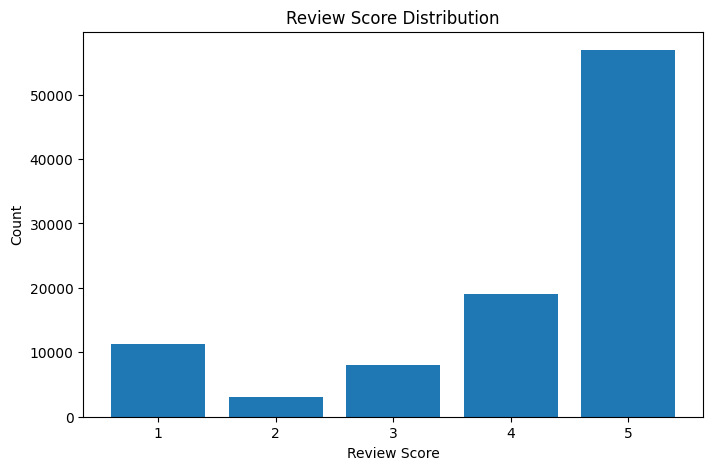

In [22]:
print("\n===== REVIEW SCORE DISTRIBUTION =====")

score_dist = (
    cleaned_reviews_df.groupBy("review_score")
    .count()
    .orderBy("review_score")
)

score_pd = score_dist.toPandas()

display(score_pd)

plt.figure(figsize=(8,5))

plt.bar(
    score_pd["review_score"],
    score_pd["count"]
)

plt.xlabel("Review Score")
plt.ylabel("Count")
plt.title("Review Score Distribution")

plt.show()


===== SENTIMENT DISTRIBUTION =====
+---------+-----+
|sentiment|count|
+---------+-----+
| positive|75917|
|  neutral| 8097|
| negative|14396|
+---------+-----+



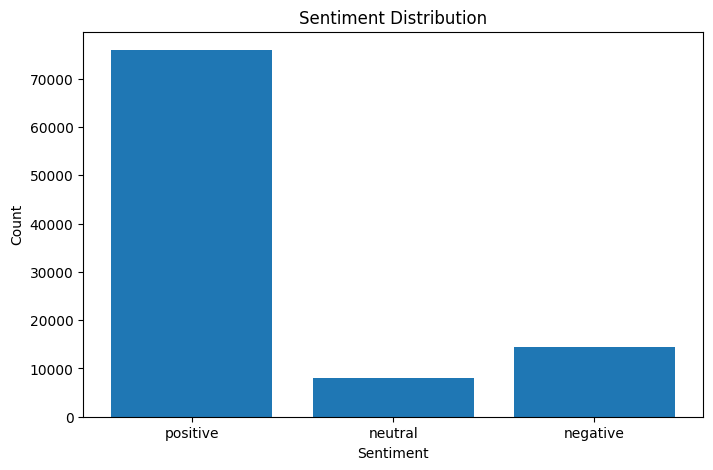

In [23]:
print("\n===== SENTIMENT DISTRIBUTION =====")

sentiment_dist = (
    cleaned_reviews_df.groupBy("sentiment")
    .count()
)

sentiment_dist.show()

sentiment_pd = sentiment_dist.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    sentiment_pd["sentiment"],
    sentiment_pd["count"]
)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")

plt.show()



===== DELIVERY STATUS DISTRIBUTION =====


,delivery_status,count
0,early,88644
1,late,6534
2,on_time,1300


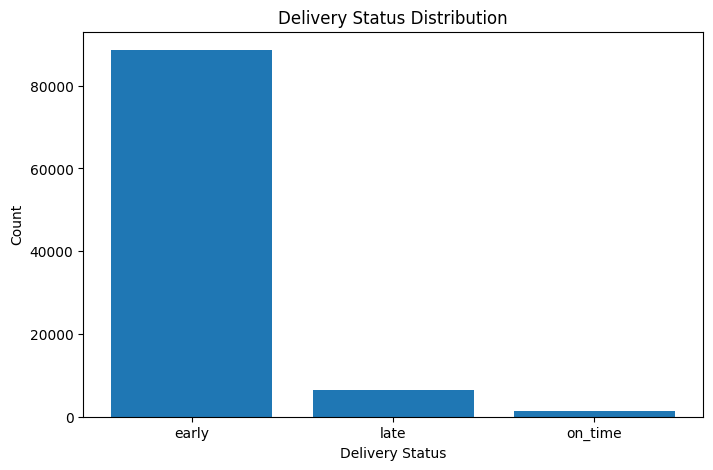

In [24]:
print("\n===== DELIVERY STATUS DISTRIBUTION =====")

delivery_status_dist = (
    orders_df.groupBy("delivery_status")
    .count()
    .orderBy("delivery_status")
)

delivery_status_pd = (
    delivery_status_dist.toPandas()
)

display(delivery_status_pd)

plt.figure(figsize=(8,5))

plt.bar(
    delivery_status_pd["delivery_status"],
    delivery_status_pd["count"]
)

plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.title("Delivery Status Distribution")

plt.show()

In [25]:
print("\n===== AVERAGE DELAY BY DELIVERY STATUS =====")

avg_delay_status = (
    orders_df.groupBy("delivery_status")
    .agg(
        avg("delivery_delay_days")
        .alias("avg_delay")
    )
)

avg_delay_pd = avg_delay_status.toPandas()

display(avg_delay_pd)


===== AVERAGE DELAY BY DELIVERY STATUS =====


,delivery_status,avg_delay
0,late,10.620141
1,on_time,0.000000
2,early,-13.707177



===== PRODUCT CATEGORY DISTRIBUTION =====


,product_category_name,count
64,fraldas_higiene,12
65,la_cuisine,10
66,moveis_colchao_e_estofado,10
67,portateis_cozinha_e_preparadores_de_alimentos,10
68,tablets_impressao_imagem,9
69,fashion_roupa_infanto_juvenil,5
70,casa_conforto_2,5
71,pc_gamer,3
72,seguros_e_servicos,2
73,cds_dvds_musicais,1


,product_category_name,count
0,cama_mesa_banho,3029
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
5,automotivo,1900
6,informatica_acessorios,1639
7,brinquedos,1411
8,relogios_presentes,1329
9,telefonia,1134


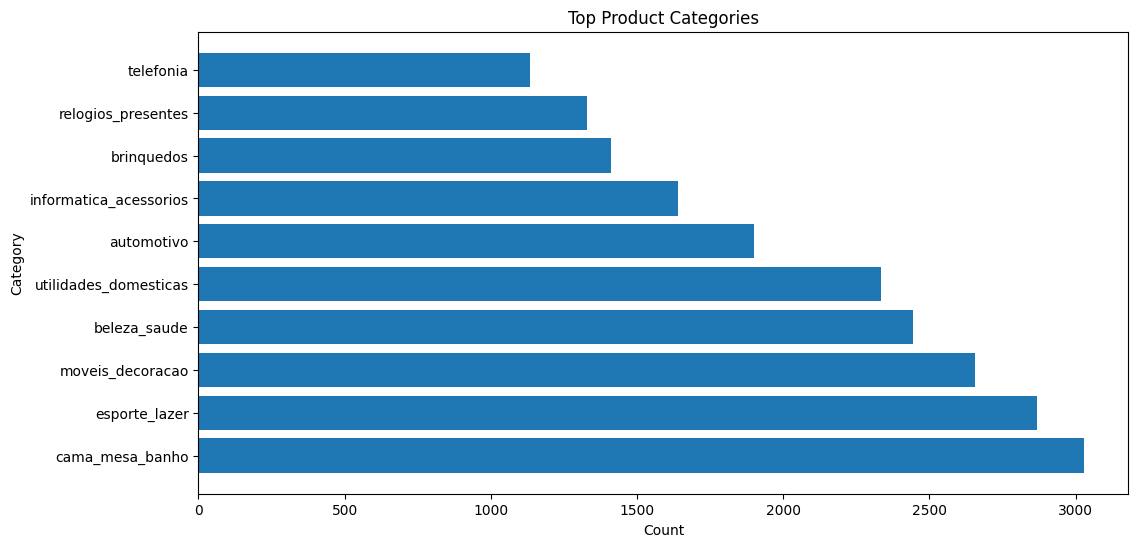

In [26]:
print("\n===== PRODUCT CATEGORY DISTRIBUTION =====")

category_dist = (
    products_df.groupBy(
        "product_category_name"
    )
    .count()
    .orderBy(desc("count"))
)

category_pd = category_dist.toPandas()

display(category_pd.tail(10))
display(category_pd.head(10))

plt.figure(figsize=(12,6))

plt.barh(
    category_pd[
        "product_category_name"
    ].head(10),
    category_pd[
        "count"
    ].head(10)
)

plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Top Product Categories")

plt.show()



===== SENTIMENT DISTRIBUTION =====
+---------+-----+
|sentiment|count|
+---------+-----+
| positive|75917|
|  neutral| 8097|
| negative|14396|
+---------+-----+



,sentiment,count
0,positive,75917
1,neutral,8097
2,negative,14396


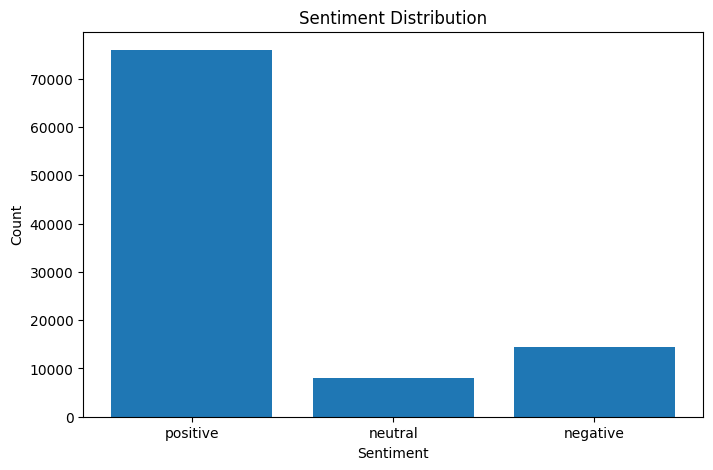

In [27]:
print("\n===== SENTIMENT DISTRIBUTION =====")

sentiment_dist = (
    cleaned_reviews_df.groupBy("sentiment")
    .count()
)

sentiment_dist.show()

sentiment_pd = sentiment_dist.toPandas()

display(sentiment_pd)

plt.figure(figsize=(8,5))

plt.bar(
    sentiment_pd["sentiment"],
    sentiment_pd["count"]
)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")

plt.show()

In [33]:
timestamp_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col_name in timestamp_columns:
    if col_name in cleaned_orders_df.columns:
        cleaned_orders_df = cleaned_orders_df.withColumn(
            col_name,
            col(col_name).cast("timestamp")
        )

cleaned_orders_df.coalesce(1).write.mode("overwrite").parquet(
    str(CLEANED_DIR / "orders_cleaned")
)
print("orders_cleaned saved")

cleaned_reviews_df.coalesce(1).write.mode("overwrite").parquet(
    str(CLEANED_DIR / "reviews_cleaned")
)
print("reviews_cleaned saved")


cleaned_products_df.coalesce(1).write.mode("overwrite").parquet(
    str(CLEANED_DIR / "products_cleaned")
)
print("products_cleaned saved")


cleaned_items_df.coalesce(1).write.mode("overwrite").parquet(
    str(CLEANED_DIR / "items_cleaned")
)
print("items_cleaned saved")


cleaned_customers_df.coalesce(1).write.mode("overwrite").parquet(
    str(CLEANED_DIR / "customers_cleaned")
)
print("customers_cleaned saved")


cleaned_sellers_df.coalesce(1).write.mode("overwrite").parquet(
    str(CLEANED_DIR / "sellers_cleaned")
)
print("sellers_cleaned saved")

translation_df.coalesce(1).write.mode("overwrite").parquet(
    str(CLEANED_DIR / "translations_cleaned")
)
print("translations_cleaned saved")

orders_cleaned saved
reviews_cleaned saved
products_cleaned saved
items_cleaned saved
customers_cleaned saved
sellers_cleaned saved
translations_cleaned saved
